# 11 â€” SHAP Analysis
TreeSHAP on the winning tree-based model per target (refit on train+val). Sanity checks: cycle history should dominate `next_cycle_length`; irregular history should dominate `next_is_irregular`. Linear/kernel/instance-based winners fall back to skipped SHAP with a note.

In [1]:

import sys, os
from pathlib import Path
root = Path.cwd()
while not (root / "src").exists() and root != root.parent:
    root = root.parent
sys.path.insert(0, str(root))
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

In [2]:
import json
import numpy as np
import pandas as pd
import shap
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC, SVR
from lightgbm import LGBMClassifier, LGBMRegressor
from xgboost import XGBClassifier, XGBRegressor
from src.config import (SPLITS_DIR, RESULTS_DIR, FIGURES_DIR, MODELS_DIR,
                        FEATURES, TARGET_CLF)
from src.tune import make_est
from src.preprocessing import build_preprocessor

trainval = pd.concat([pd.read_csv(SPLITS_DIR / "train.csv"), pd.read_csv(SPLITS_DIR / "val.csv")], ignore_index=True)
winners = json.load(open(RESULTS_DIR / "winners.json"))

def default_est(kind, name, spw=1.0):
    if kind == "reg":
        table = {
            "ridge": lambda: Ridge(random_state=42),
            "random_forest": lambda: RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
            "xgboost": lambda: XGBRegressor(n_estimators=500, random_state=42, n_jobs=-1, tree_method="hist", eval_metric="mae", verbosity=0),
            "lightgbm": lambda: LGBMRegressor(n_estimators=500, random_state=42, n_jobs=-1, verbose=-1),
            "svr": lambda: SVR(),
            "knn": lambda: KNeighborsRegressor(),
        }
    else:
        table = {
            "logistic_regression": lambda: LogisticRegression(class_weight="balanced", max_iter=2000, random_state=42),
            "random_forest": lambda: RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1),
            "xgboost": lambda: XGBClassifier(n_estimators=500, scale_pos_weight=spw, random_state=42, n_jobs=-1, tree_method="hist", eval_metric="aucpr", verbosity=0),
            "lightgbm": lambda: LGBMClassifier(n_estimators=500, is_unbalance=True, random_state=42, n_jobs=-1, verbose=-1),
            "svc": lambda: SVC(class_weight="balanced", probability=True, random_state=42),
            "knn": lambda: KNeighborsClassifier(),
        }
    return table[name]()

TREE_MODELS = {"xgboost", "lightgbm", "random_forest"}

def fit_and_shap(kind, winner_name, target):
    base = winner_name.replace("_tuned", "")
    spw = 1.0
    y = trainval[target]
    if kind == "clf":
        yi = y.astype(int)
        spw = float((yi == 0).sum()) / max((yi == 1).sum(), 1)
    params = {}
    if winner_name.endswith("_tuned"):
        tuned_file = RESULTS_DIR / "optuna" / f"{kind}_{base}_{target}_best.json"
        if tuned_file.exists():
            params = json.load(open(tuned_file))["best_params"]
    est = make_est(kind, base, params, spw=spw)
    prep = build_preprocessor()
    Xt = prep.fit_transform(trainval[FEATURES])
    est.fit(Xt, yi if kind == "clf" else y)
    sample = shap.sample(Xt, 120, random_state=42)
    explainer = shap.TreeExplainer(est)
    sv = explainer.shap_values(sample, check_additivity=False)
    vals = np.asarray(sv[1] if isinstance(sv, list) else sv)
    if vals.ndim == 3:
        vals = vals[:, :, -1]
    names = [str(n).split("__")[-1] for n in prep.get_feature_names_out()]
    plt.figure(figsize=(9, 7))
    shap.summary_plot(vals, sample, feature_names=names, show=False)
    plt.title(f"SHAP - {target}")
    plt.tight_layout(); plt.savefig(FIGURES_DIR / f"shap_{target}.png", dpi=150); plt.show()
    plt.close("all")
    means = np.abs(vals).mean(axis=0)
    order = np.argsort(means)[::-1][:10]
    top = [{"feature": names[i], "mean_abs_shap": round(float(means[i]), 5)} for i in order]
    joblib.dump({"prep": prep, "model": est}, MODELS_DIR / f"final_{target}.joblib")
    return top


## Compute SHAP per winning model

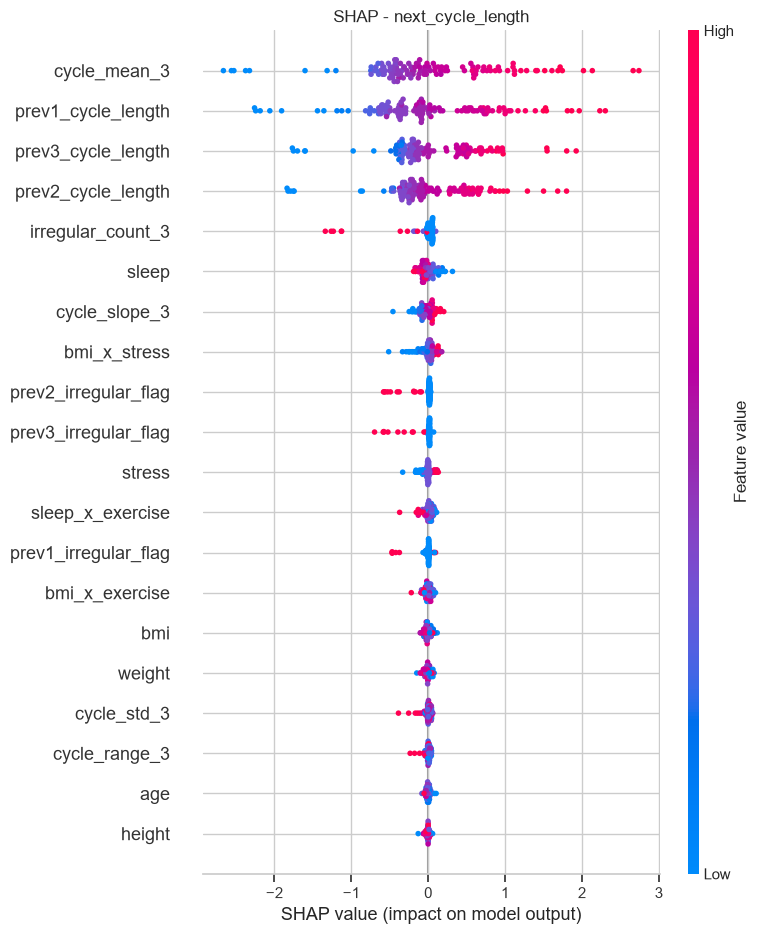

next_cycle_length top: [{'feature': 'cycle_mean_3', 'mean_abs_shap': 0.68838}, {'feature': 'prev1_cycle_length', 'mean_abs_shap': 0.6483}, {'feature': 'prev3_cycle_length', 'mean_abs_shap': 0.46109}]


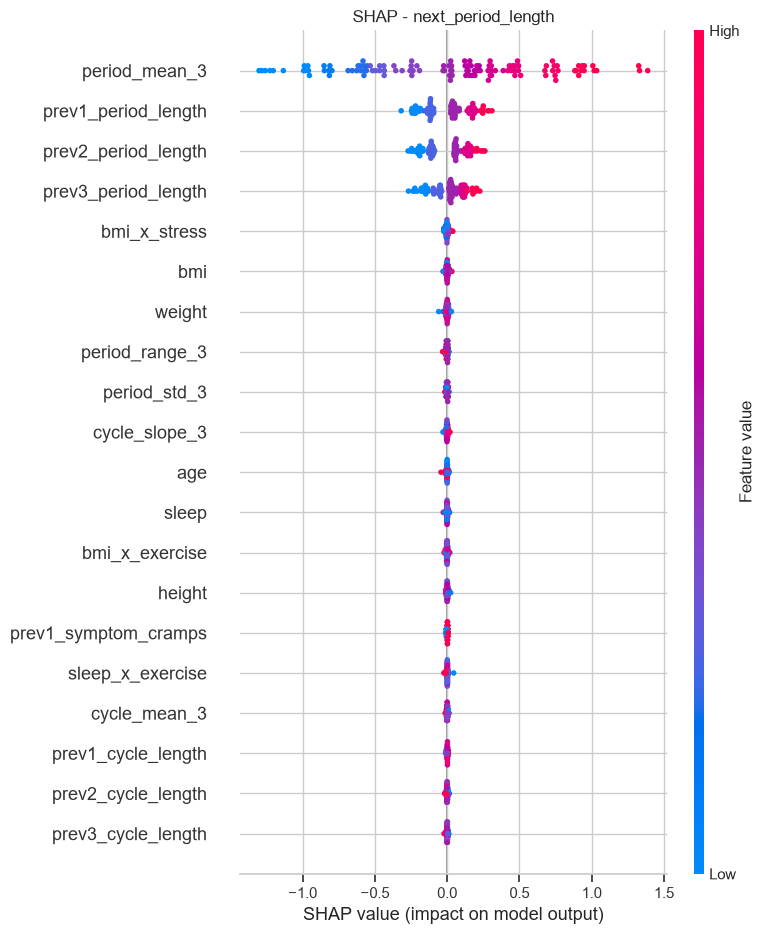

next_period_length top: [{'feature': 'period_mean_3', 'mean_abs_shap': 0.53959}, {'feature': 'prev1_period_length', 'mean_abs_shap': 0.14014}, {'feature': 'prev2_period_length', 'mean_abs_shap': 0.1311}]


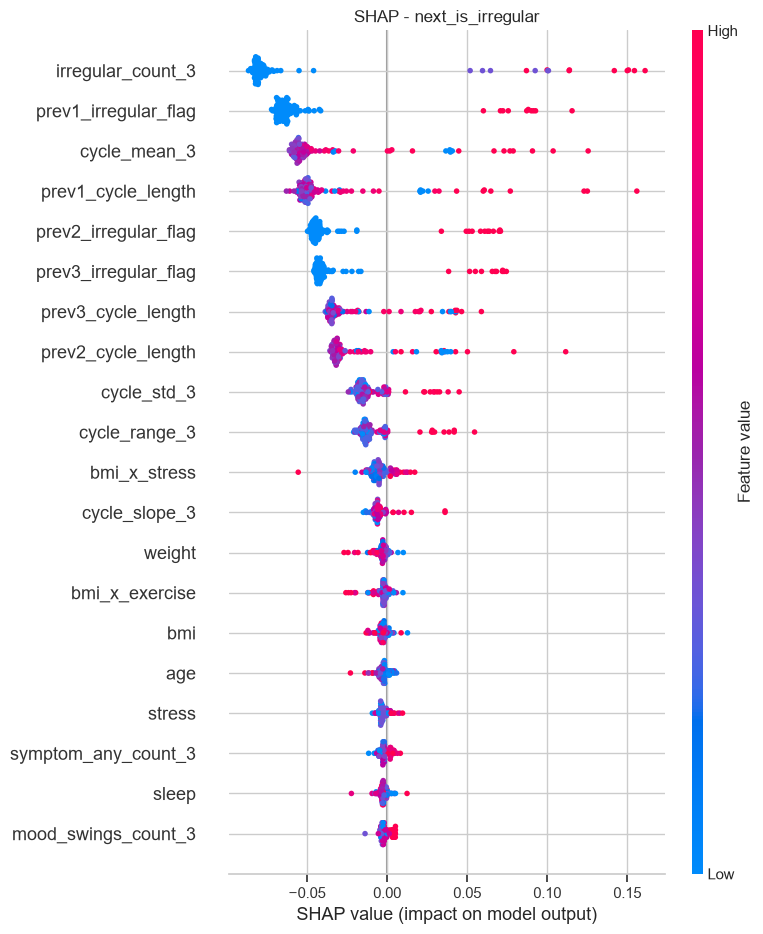

next_is_irregular top: [{'feature': 'irregular_count_3', 'mean_abs_shap': 0.08285}, {'feature': 'prev1_irregular_flag', 'mean_abs_shap': 0.06504}, {'feature': 'cycle_mean_3', 'mean_abs_shap': 0.0526}]


In [3]:
import joblib

shap_top = {}
skipped = {}
for w in winners["regression"]:
    target, winner_name = w["target"], w["model"]
    if winner_name.replace("_tuned", "") in TREE_MODELS:
        shap_top[target] = fit_and_shap("reg", winner_name, target)
        print(target, "top:", shap_top[target][:3], flush=True)
    else:
        skipped[target] = f"{winner_name} is not tree-based; SHAP summary skipped"
        print(skipped[target])
winner_name = winners["classification"]["model"]
if winner_name.replace("_tuned", "") in TREE_MODELS:
    shap_top[TARGET_CLF] = fit_and_shap("clf", winner_name, TARGET_CLF)
    print(TARGET_CLF, "top:", shap_top[TARGET_CLF][:3], flush=True)
else:
    skipped[TARGET_CLF] = f"{winner_name} is not tree-based; SHAP summary skipped"
json.dump({"top_features": shap_top, "skipped": skipped}, open(RESULTS_DIR / "shap_top_features.json", "w"), indent=2)


## Sanity checks

In [4]:
checks = []
def add_check(target, label, keyword):
    if target in shap_top:
        tops = [d["feature"] for d in shap_top[target]][:5]
        checks.append({"check": label, "pass": any(keyword in t for t in tops), "top5": tops})

add_check("next_cycle_length", "cycle-length history dominates next_cycle_length", "cycle")
add_check("next_period_length", "period history dominates next_period_length", "period")
add_check(TARGET_CLF, "irregular history drives irregular classifier", "irregular")
pd.DataFrame(checks)


,check,pass,top5
0,cycle-length history dominates next_cycle_length,True,"[cycle_mean_3, prev1_cycle_length, prev3_cycle..."
1,period history dominates next_period_length,True,"[period_mean_3, prev1_period_length, prev2_per..."
2,irregular history drives irregular classifier,True,"[irregular_count_3, prev1_irregular_flag, cycl..."


## Added diagnostics — mean |SHAP| bar plots & dependence plots\nBar-ranked importance per target plus dependence plots for the top-3 features (linearity vs nonlinear kinks). SHAP values persisted to reports/metrics/shap_vals/.

computing SHAP for next_cycle_length


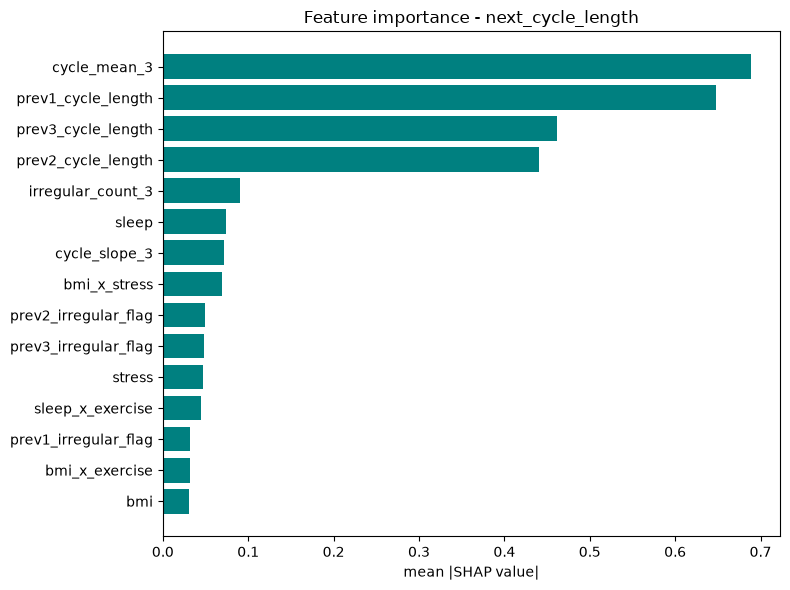

next_cycle_length top-3: ['cycle_mean_3', 'prev1_cycle_length', 'prev3_cycle_length']


<Figure size 750x500 with 0 Axes>

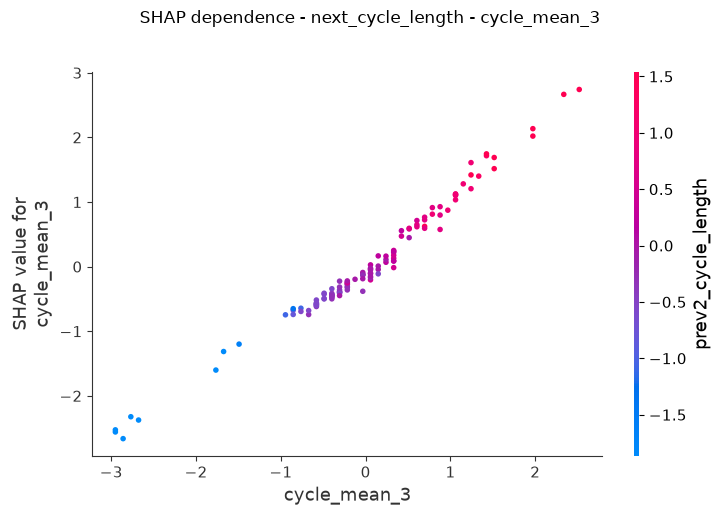

<Figure size 750x500 with 0 Axes>

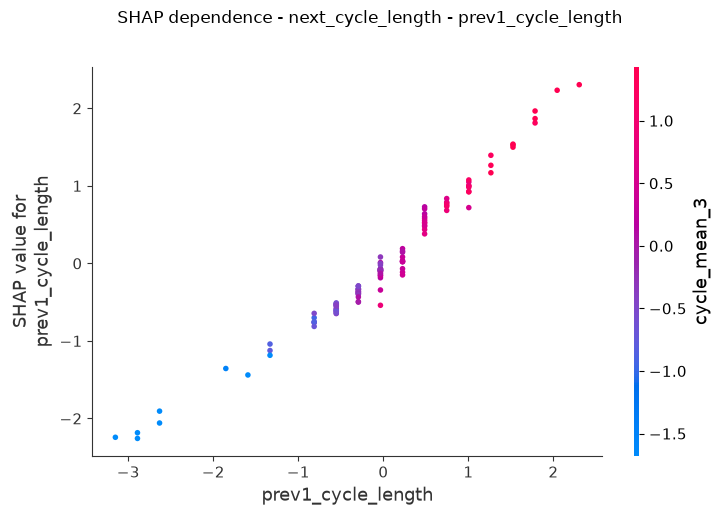

<Figure size 750x500 with 0 Axes>

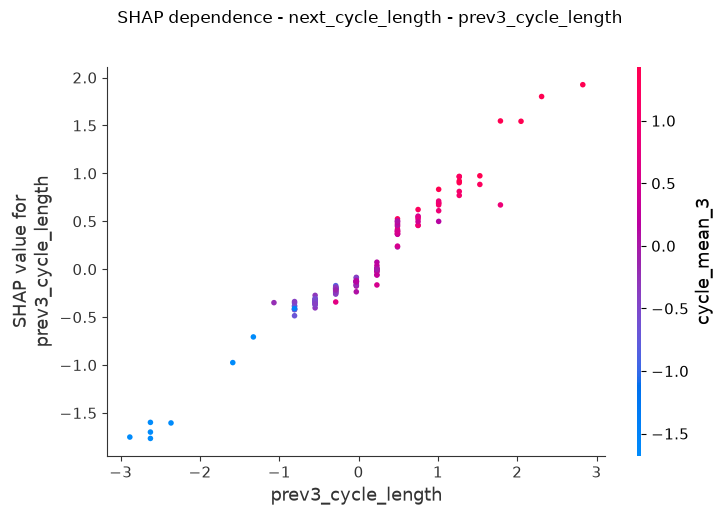

computing SHAP for next_period_length


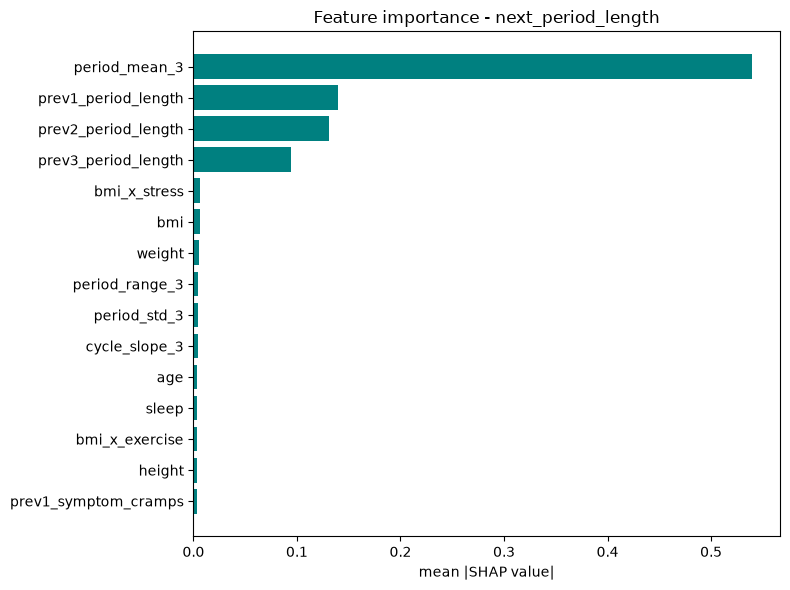

next_period_length top-3: ['period_mean_3', 'prev1_period_length', 'prev2_period_length']


<Figure size 750x500 with 0 Axes>

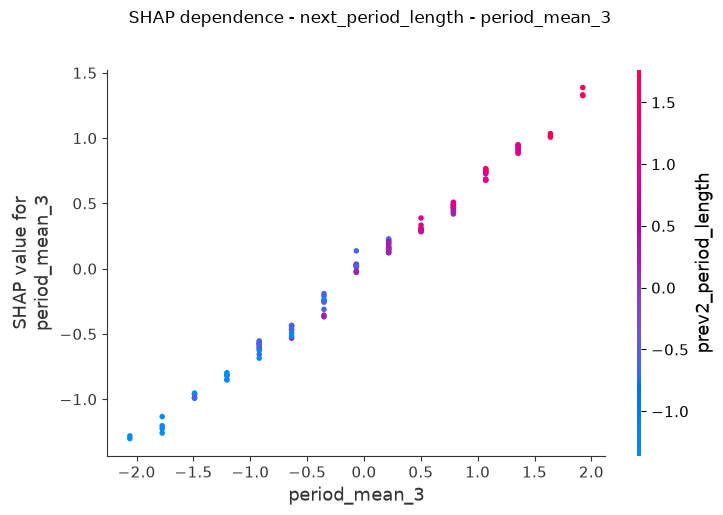

<Figure size 750x500 with 0 Axes>

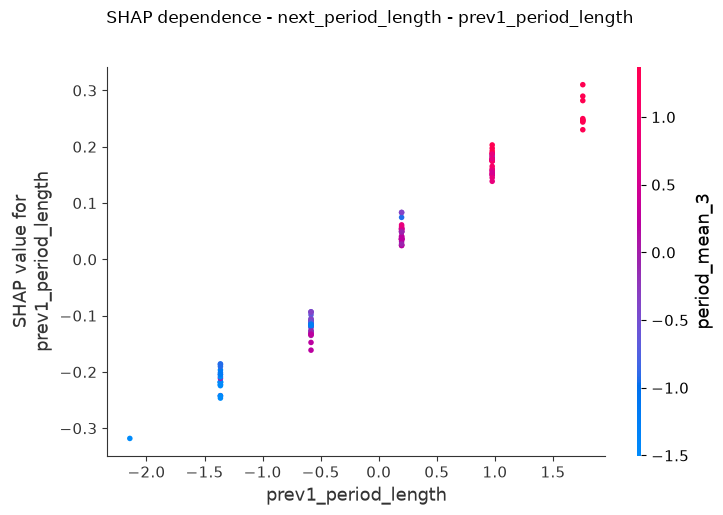

<Figure size 750x500 with 0 Axes>

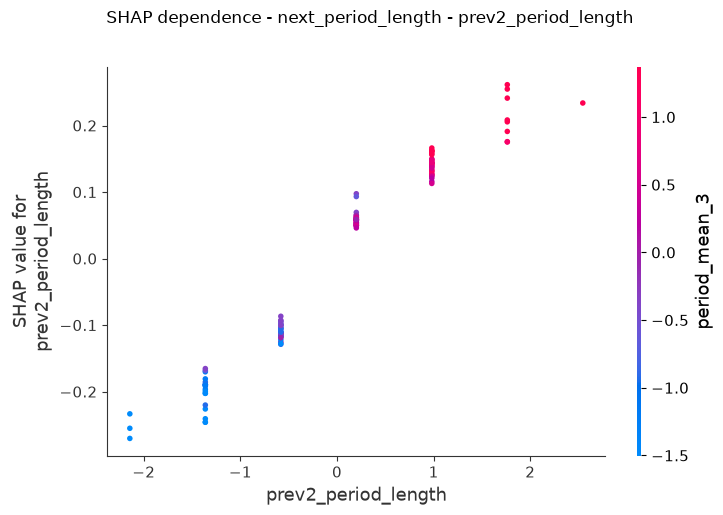

computing SHAP for next_is_irregular


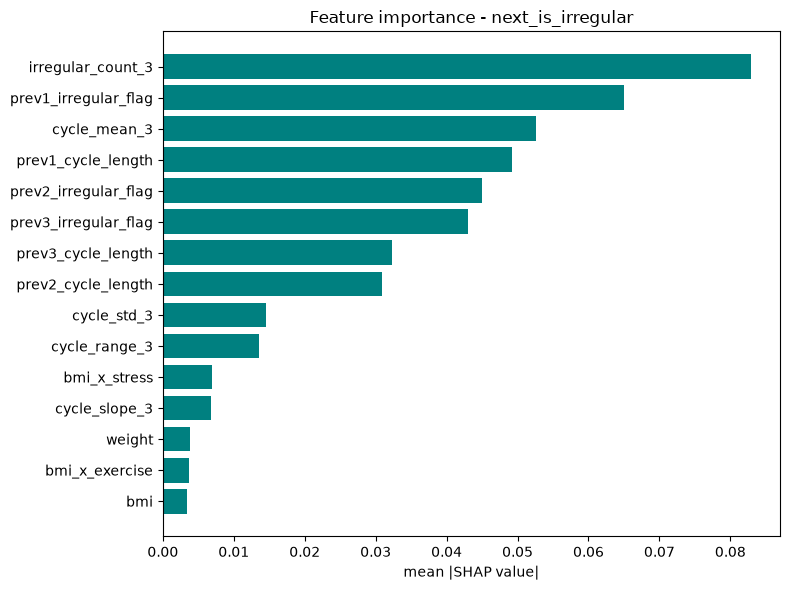

next_is_irregular top-3: ['irregular_count_3', 'prev1_irregular_flag', 'cycle_mean_3']


<Figure size 750x500 with 0 Axes>

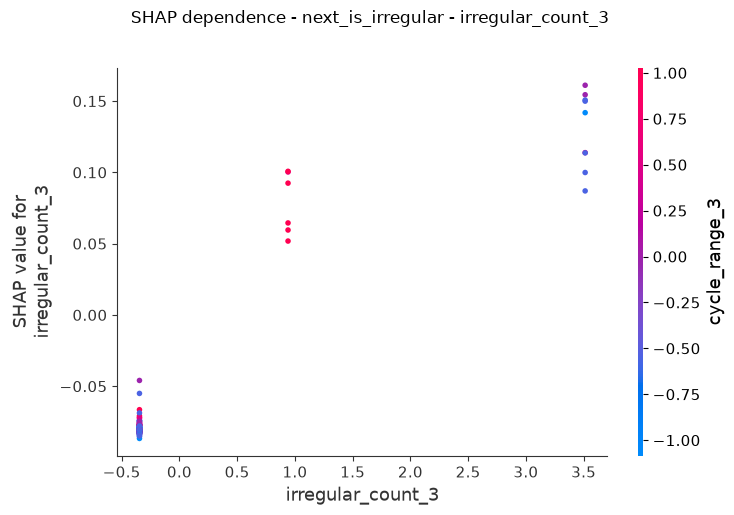

<Figure size 750x500 with 0 Axes>

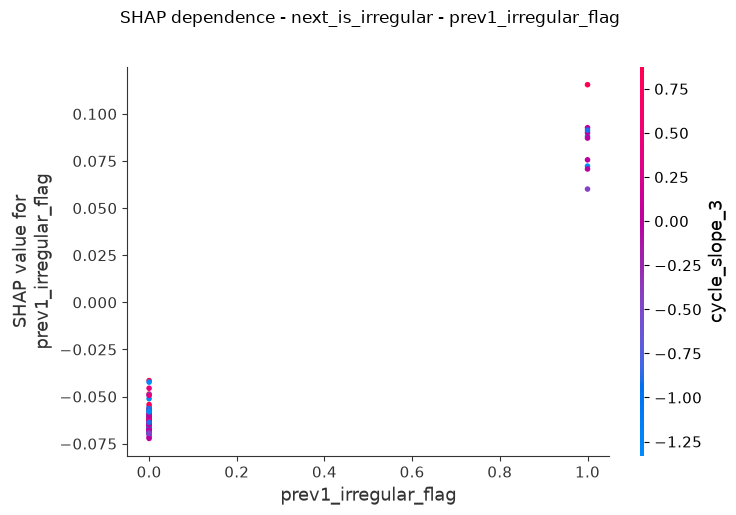

<Figure size 750x500 with 0 Axes>

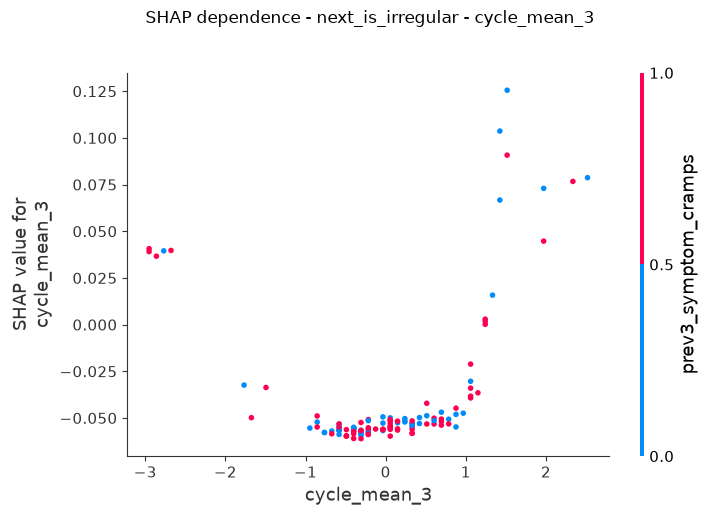

In [2]:
for target in TARGETS_REG + [TARGET_CLF]:
    print("computing SHAP for", target, flush=True)
    vals, sample, names = compute_shap(target)
    means = np.abs(vals).mean(axis=0)
    order = np.argsort(means)[::-1]
    top_idx = order[:15]
    plt.figure(figsize=(8, 6))
    plt.barh(range(len(top_idx)), means[top_idx][::-1], color="teal")
    plt.yticks(range(len(top_idx)), [names[i] for i in top_idx][::-1])
    plt.xlabel("mean |SHAP value|")
    plt.title(f"Feature importance - {target}")
    plt.tight_layout(); plt.savefig(FIGURES_DIR / f"shap_bar_{target}.png", dpi=150); plt.show()

    top3 = [names[i] for i in order[:3]]
    print(target, "top-3:", top3, flush=True)
    for feat in top3:
        fi = names.index(feat)
        plt.figure(figsize=(7.5, 5))
        shap.dependence_plot(fi, vals, sample, feature_names=names, show=False)
        plt.gcf().suptitle(f"SHAP dependence - {target} - {feat}", y=1.02)
        plt.tight_layout()
        safe = feat.replace("/", "_")
        plt.savefig(FIGURES_DIR / f"shap_dep_{target}_{safe}.png", dpi=150, bbox_inches="tight")
        plt.show(); plt.close("all")
